# Pipeline CNN para actividades (dataset_preparado.csv)
En este notebook entrenamos una CNN 1D con: ventanas temporales, division train/test, normalizacion y codificacion de etiquetas.


In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv1D, BatchNormalization, ReLU, MaxPooling1D, Dropout, GlobalAveragePooling1D, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical


In [2]:
# Reproducibilidad
SEED = 42

import os
import random
import numpy as np
import tensorflow as tf

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Configuración principal
CSV_PATH = "data/dataset_preparado.csv"

FEATURE_COLS = ["AccX", "AccY", "AccZ", "GyrX", "GyrY", "GyrZ"]
LABEL_COL = "activity"
PERSON_COL = "person_id"
GROUP_COLS = [PERSON_COL, LABEL_COL]
SORT_COL = "sample_index"

# Ventanas temporales
SAMPLE_RATE_HZ = 64        # confirmar según el notebook/dataset real
WINDOW_SECONDS = 2.0
WINDOW_SIZE = int(SAMPLE_RATE_HZ * WINDOW_SECONDS)
WINDOW_STEP = WINDOW_SIZE // 2   # solape del 50%

# Split por persona
TEST_SIZE = 0.20
VAL_SIZE = 0.20

# Entrenamiento
BATCH_SIZE = 128
EPOCHS = 50

In [3]:
# Carga de datos
df = pd.read_csv(CSV_PATH)

required_cols = list(dict.fromkeys(FEATURE_COLS + [LABEL_COL, SORT_COL] + GROUP_COLS))
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Faltan columnas requeridas: {missing}")

# Tipado y limpieza mínima
df = df.copy()

df[FEATURE_COLS] = df[FEATURE_COLS].apply(pd.to_numeric, errors="coerce")
df[SORT_COL] = pd.to_numeric(df[SORT_COL], errors="coerce")

df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip()
df["person_id"] = df["person_id"].astype(str).str.strip()

df = df.dropna(
    subset=FEATURE_COLS + [LABEL_COL, SORT_COL, "person_id"]
).reset_index(drop=True)

# Orden base
df = df.sort_values(["person_id", LABEL_COL, SORT_COL]).reset_index(drop=True)

print("Shape después de limpieza:", df.shape)
print("Clases:", df[LABEL_COL].value_counts().to_dict())
print("Personas:", df["person_id"].nunique())
df.head()

Shape después de limpieza: (1412865, 9)
Clases: {'caminando': 344288, 'sentado': 338778, 'parado': 306427, 'subiendo_escaleras': 157285, 'trotando': 134231, 'bajando_escaleras': 131856}
Personas: 24


,sample_index,AccX,AccY,AccZ,GyrX,GyrY,GyrZ,activity,person_id
0,0,0.219405,0.035846,0.114866,0.316738,0.424446,0.643574,bajando_escaleras,sub_1
1,0,-0.160289,-0.187298,0.587390,0.969699,-4.170838,1.271234,bajando_escaleras,sub_1
2,0,-0.432808,-0.134344,0.312718,0.091025,-0.944193,-0.012691,bajando_escaleras,sub_1
3,1,0.184623,0.052322,0.111548,0.259781,0.346915,0.593572,bajando_escaleras,sub_1
4,1,-0.164738,-0.190748,0.558335,0.925435,-4.034956,1.206123,bajando_escaleras,sub_1


In [5]:
def create_temporal_windows(dataframe, feature_cols, label_col, group_cols, sort_col, window_size, step):
    X_windows = []
    y_windows = []

    grouped = dataframe.sort_values(group_cols + [sort_col]).groupby(group_cols, sort=False)

    for _, group_df in grouped:
        signal = group_df[feature_cols].to_numpy(dtype=np.float32)
        labels = group_df[label_col].to_numpy()

        n = len(group_df)
        if n < window_size:
            continue

        for start in range(0, n - window_size + 1, step):
            end = start + window_size
            X_windows.append(signal[start:end])
            # Etiqueta de la ventana: clase mayoritaria (normalmente sera unica por grupo)
            window_label = pd.Series(labels[start:end]).mode().iloc[0]
            y_windows.append(window_label)

    X = np.asarray(X_windows, dtype=np.float32)
    y = np.asarray(y_windows)
    return X, y


X, y = create_temporal_windows(
    dataframe=df,
    feature_cols=FEATURE_COLS,
    label_col=LABEL_COL,
    group_cols=GROUP_COLS,
    sort_col=SORT_COL,
    window_size=WINDOW_SIZE,
    step=WINDOW_STEP,
)

print("Ventanas creadas:", X.shape)
print("Etiquetas ventanas:", y.shape)


Ventanas creadas: (21864, 128, 6)
Etiquetas ventanas: (21864,)


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

# X: ventanas
# y: etiquetas raw
# groups: person_id de cada ventana

if len(X) != len(y) or len(X) != len(groups):
    raise ValueError(
        f"X, y y groups deben tener la misma longitud. "
        f"X={len(X)}, y={len(y)}, groups={len(groups)}"
    )

# 1) División train/test por persona
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_SIZE,
    random_state=SEED,
)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train_raw, y_test_raw = y[train_idx], y[test_idx]

groups_train = groups[train_idx]
groups_test = groups[test_idx]

print("Train:", X_train.shape, y_train_raw.shape)
print("Test:", X_test.shape, y_test_raw.shape)

print("Personas train:", sorted(set(groups_train)))
print("Personas test:", sorted(set(groups_test)))

overlap = set(groups_train).intersection(set(groups_test))
if overlap:
    raise ValueError(f"Data leakage: personas repetidas en train y test: {overlap}")

print("Distribución train:", pd.Series(y_train_raw).value_counts().to_dict())
print("Distribución test:", pd.Series(y_test_raw).value_counts().to_dict())

Train: (17491, 128, 6) (17491,)
Test: (4373, 128, 6) (4373,)


In [7]:
# 2) Normalizacion (fit solo en train)
scaler = StandardScaler()

n_train, t_steps, n_features = X_train.shape
n_test = X_test.shape[0]

X_train_2d = X_train.reshape(-1, n_features)
X_test_2d = X_test.reshape(-1, n_features)

X_train_scaled = scaler.fit_transform(X_train_2d).reshape(n_train, t_steps, n_features)
X_test_scaled = scaler.transform(X_test_2d).reshape(n_test, t_steps, n_features)

# 3) Codificacion de etiquetas
label_encoder = LabelEncoder()
y_train_int = label_encoder.fit_transform(y_train_raw)
y_test_int = label_encoder.transform(y_test_raw)

num_classes = len(label_encoder.classes_)
y_train = to_categorical(y_train_int, num_classes=num_classes)
y_test = to_categorical(y_test_int, num_classes=num_classes)

print("Clases codificadas:", list(label_encoder.classes_))
print("X_train_scaled:", X_train_scaled.shape, "y_train:", y_train.shape)
print("X_test_scaled:", X_test_scaled.shape, "y_test:", y_test.shape)


Clases codificadas: [np.str_('bajando_escaleras'), np.str_('caminando'), np.str_('parado'), np.str_('sentado'), np.str_('subiendo_escaleras'), np.str_('trotando')]
X_train_scaled: (17491, 128, 6) y_train: (17491, 6)
X_test_scaled: (4373, 128, 6) y_test: (4373, 6)


In [8]:
def build_cnn_model(input_shape, num_classes):
    model = Sequential([
        Conv1D(64, kernel_size=5, padding="same", input_shape=input_shape),
        BatchNormalization(),
        ReLU(),
        MaxPooling1D(pool_size=2),
        Dropout(0.2),

        Conv1D(128, kernel_size=3, padding="same"),
        BatchNormalization(),
        ReLU(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),

        Conv1D(256, kernel_size=3, padding="same"),
        BatchNormalization(),
        ReLU(),
        GlobalAveragePooling1D(),

        Dense(128, activation="relu"),
        Dropout(0.3),
        Dense(num_classes, activation="softmax"),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


model = build_cnn_model(
    input_shape=(X_train_scaled.shape[1], X_train_scaled.shape[2]),
    num_classes=num_classes,
)
model.summary()


c:\Users\Alumno_AI\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 128, 64)        │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 64, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 32, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,710 (627.77 KB)

 Trainable params: 159,814 (624.27 KB)

 Non-trainable params: 896 (3.50 KB)

In [9]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5),
]

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.7410 - loss: 0.5825 - val_accuracy: 0.7614 - val_loss: 0.5928 - learning_rate: 0.0010
Epoch 2/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.8764 - loss: 0.3270 - val_accuracy: 0.8797 - val_loss: 0.3287 - learning_rate: 0.0010
Epoch 3/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9032 - loss: 0.2617 - val_accuracy: 0.8848 - val_loss: 0.3027 - learning_rate: 0.0010
Epoch 4/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.9175 - loss: 0.2240 - val_accuracy: 0.9274 - val_loss: 0.2115 - learning_rate: 0.0010
Epoch 5/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.9248 - loss: 0.2024 - val_accuracy: 0.9460 - val_loss: 0.1636 - learning_rate: 0.0010
Epoch 6/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.9309 - loss: 0.1854 - val_accuracy: 0.9491 - val_loss: 0.1583 - learning_rate: 0.0010
Epoch 7/25
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.9331 - loss: 0.

Test loss: 0.0795
Test accuracy: 0.9730
                    precision    recall  f1-score   support

 bajando_escaleras       0.98      0.97      0.98       404
         caminando       0.99      0.99      0.99      1069
            parado       0.98      0.93      0.95       951
           sentado       0.94      0.98      0.96      1051
subiendo_escaleras       0.96      0.98      0.97       485
          trotando       1.00      0.99      0.99       413

          accuracy                           0.97      4373
         macro avg       0.98      0.97      0.97      4373
      weighted avg       0.97      0.97      0.97      4373



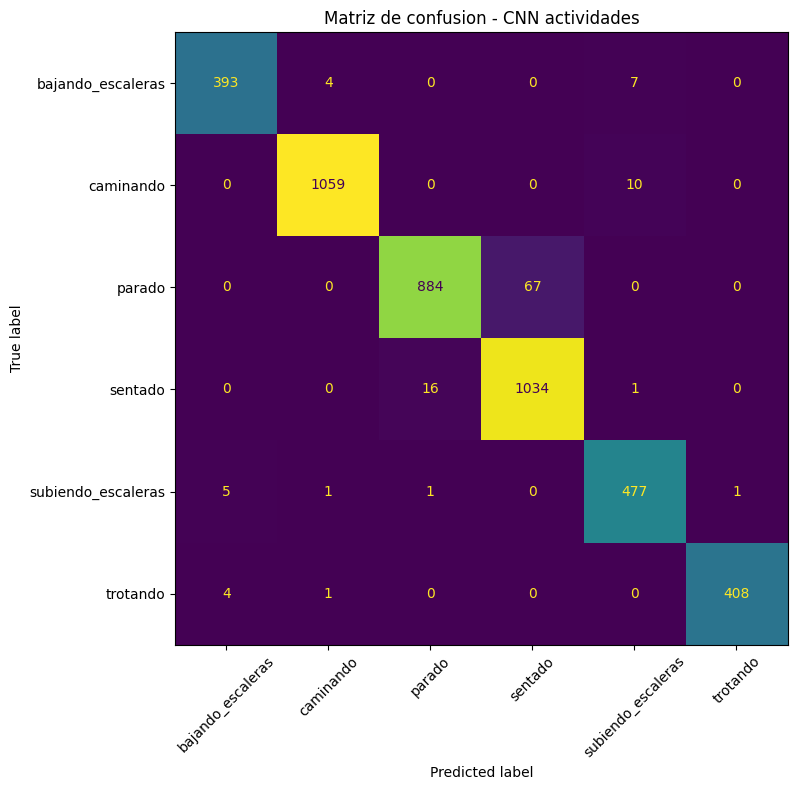

In [10]:
# Evaluacion en test
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

y_pred_prob = model.predict(X_test_scaled, verbose=0)
y_pred_int = np.argmax(y_pred_prob, axis=1)
y_true_int = np.argmax(y_test, axis=1)

print(classification_report(y_true_int, y_pred_int, target_names=label_encoder.classes_))

cm = confusion_matrix(y_true_int, y_pred_int)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Matriz de confusion - CNN actividades")
plt.tight_layout()
plt.show()


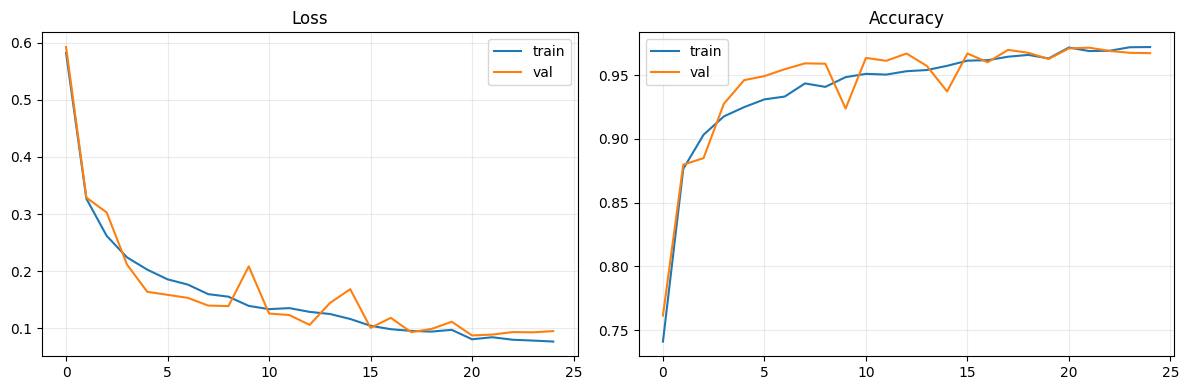

In [11]:
# Curvas de entrenamiento
history_df = pd.DataFrame(history.history)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history_df["loss"], label="train")
ax[0].plot(history_df["val_loss"], label="val")
ax[0].set_title("Loss")
ax[0].legend()
ax[0].grid(alpha=0.25)

ax[1].plot(history_df["accuracy"], label="train")
ax[1].plot(history_df["val_accuracy"], label="val")
ax[1].set_title("Accuracy")
ax[1].legend()
ax[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


In [12]:
model.save("modelo_cnn_actividad.keras")

print("Modelo guardado correctamente como modelo_cnn_actividad.keras")

Modelo guardado correctamente como modelo_cnn_actividad.keras


## Seccion RNN - KFall (deteccion de caidas)
En esta seccion construimos un **dataset maestro** a partir de todos los sensores `SAxx` del `KFall Dataset`, uniendo cada CSV con su `SAxx_label.xlsx`, y entrenamos un RNN (LSTM) para deteccion binaria de caida.


In [13]:
import re
from pathlib import Path

# Rutas y configuracion KFall
KFALL_ROOT = Path("data/KFall Dataset")
MASTER_DATASET_PATH = Path("data/kfall_dataset_maestro.csv")

KFALL_FEATURE_COLS = ["AccX", "AccY", "AccZ", "GyrX", "GyrY", "GyrZ"]

# Configuracion de ventanas para RNN
RNN_WINDOW_SIZE = 128
RNN_WINDOW_STEP = 32
FALL_RATIO_THRESHOLD = 0.20  # Si >=20% de la ventana esta en fase de caida, etiqueta 1

RNN_TEST_SIZE = 0.20
RNN_BATCH_SIZE = 128
RNN_EPOCHS = 20

FILE_PATTERN = re.compile(r"^S(?P<sensor>\d+)T(?P<task>\d+)R(?P<trial>\d+)\.csv$", re.IGNORECASE)
TASK_ID_PATTERN = re.compile(r"\((\d+)\)")


In [14]:
def read_sensor_label_xlsx(label_path: Path) -> pd.DataFrame:
    label_df = pd.read_excel(label_path)
    expected = {"Task Code (Task ID)", "Description", "Trial ID", "Fall_onset_frame", "Fall_impact_frame"}
    missing = expected - set(label_df.columns)
    if missing:
        raise ValueError(f"Columnas faltantes en {label_path.name}: {sorted(missing)}")

    label_df = label_df.copy()
    label_df["Task Code (Task ID)"] = label_df["Task Code (Task ID)"].ffill()
    label_df["Description"] = label_df["Description"].ffill()

    label_df["task_id"] = label_df["Task Code (Task ID)"].astype(str).str.extract(TASK_ID_PATTERN).astype(float)
    label_df["task_id"] = label_df["task_id"].astype("Int64")
    label_df["trial_id"] = pd.to_numeric(label_df["Trial ID"], errors="coerce").astype("Int64")
    label_df["fall_onset_frame"] = pd.to_numeric(label_df["Fall_onset_frame"], errors="coerce").astype("Int64")
    label_df["fall_impact_frame"] = pd.to_numeric(label_df["Fall_impact_frame"], errors="coerce").astype("Int64")

    label_df = label_df.dropna(subset=["task_id", "trial_id", "fall_onset_frame", "fall_impact_frame"]).copy()
    label_df["task_id"] = label_df["task_id"].astype(int)
    label_df["trial_id"] = label_df["trial_id"].astype(int)
    label_df["fall_onset_frame"] = label_df["fall_onset_frame"].astype(int)
    label_df["fall_impact_frame"] = label_df["fall_impact_frame"].astype(int)

    return label_df[[
        "Task Code (Task ID)",
        "Description",
        "task_id",
        "trial_id",
        "fall_onset_frame",
        "fall_impact_frame",
    ]].rename(columns={
        "Task Code (Task ID)": "task_code",
        "Description": "task_description",
    })


In [15]:
def build_kfall_master_dataset(kfall_root: Path, feature_cols: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    all_parts = []
    skipped = []

    sensor_dirs = sorted([p for p in kfall_root.glob("SA*") if p.is_dir()])

    for sensor_dir in sensor_dirs:
        label_path = sensor_dir / f"{sensor_dir.name}_label.xlsx"
        if not label_path.exists():
            skipped.append({"sensor_dir": sensor_dir.name, "reason": "label_xlsx_missing"})
            continue

        label_df = read_sensor_label_xlsx(label_path)
        csv_files = sorted(sensor_dir.glob("S*T*R*.csv"))

        for csv_path in csv_files:
            match = FILE_PATTERN.match(csv_path.name)
            if not match:
                skipped.append({"sensor_dir": sensor_dir.name, "file": csv_path.name, "reason": "filename_pattern_no_match"})
                continue

            sensor_id = int(match.group("sensor"))
            task_id = int(match.group("task"))
            trial_id = int(match.group("trial"))

            # En label solo aparecen las tareas de caida (F01..F15 => task_id 20..34)
            label_match = label_df[(label_df["task_id"] == task_id) & (label_df["trial_id"] == trial_id)]
            if label_match.empty:
                skipped.append({
                    "sensor_dir": sensor_dir.name,
                    "file": csv_path.name,
                    "reason": "label_not_found_for_task_trial",
                    "task_id": task_id,
                    "trial_id": trial_id,
                })
                continue

            row = label_match.iloc[0]
            onset = int(row["fall_onset_frame"])
            impact = int(row["fall_impact_frame"])

            use_cols = ["TimeStamp(s)", "FrameCounter"] + feature_cols
            df_trial = pd.read_csv(csv_path, usecols=use_cols)

            df_trial[feature_cols] = df_trial[feature_cols].apply(pd.to_numeric, errors="coerce")
            df_trial["FrameCounter"] = pd.to_numeric(df_trial["FrameCounter"], errors="coerce")
            df_trial["TimeStamp(s)"] = pd.to_numeric(df_trial["TimeStamp(s)"], errors="coerce")
            df_trial = df_trial.dropna(subset=feature_cols + ["FrameCounter", "TimeStamp(s)"]).copy()

            frame = df_trial["FrameCounter"].astype(int)
            phase = np.select(
                [frame < onset, (frame >= onset) & (frame <= impact), frame > impact],
                ["pre_fall", "falling", "post_fall"],
                default="unknown",
            )

            df_trial["fall_phase"] = phase
            df_trial["fall_binary"] = (df_trial["fall_phase"] == "falling").astype(np.int8)
            df_trial["sensor_folder"] = sensor_dir.name
            df_trial["sensor_id"] = sensor_id
            df_trial["task_id"] = task_id
            df_trial["trial_id"] = trial_id
            df_trial["task_code"] = row["task_code"]
            df_trial["task_description"] = row["task_description"]
            df_trial["fall_onset_frame"] = onset
            df_trial["fall_impact_frame"] = impact
            df_trial["source_file"] = csv_path.name

            all_parts.append(df_trial)

    if not all_parts:
        raise ValueError("No se pudieron construir registros del dataset maestro KFall.")

    master_df = pd.concat(all_parts, ignore_index=True)
    skipped_df = pd.DataFrame(skipped)
    return master_df, skipped_df


In [16]:
kfall_master_df, skipped_files_df = build_kfall_master_dataset(
    kfall_root=KFALL_ROOT,
    feature_cols=KFALL_FEATURE_COLS,
)

# Guardamos dataset maestro para reutilizar en proximas ejecuciones
kfall_master_df.to_csv(MASTER_DATASET_PATH, index=False)

print("Dataset maestro guardado en:", MASTER_DATASET_PATH)
print("Shape maestro:", kfall_master_df.shape)
print("Distribucion fall_binary:")
print(kfall_master_df["fall_binary"].value_counts(normalize=True).rename("ratio"))
print("Trials unicos:", kfall_master_df[["sensor_id", "task_id", "trial_id"]].drop_duplicates().shape[0])

if not skipped_files_df.empty:
    print("Archivos omitidos:", len(skipped_files_df))
    display(skipped_files_df.head(10))

kfall_master_df.head()


Dataset maestro guardado en: data\kfall_dataset_maestro.csv
Shape maestro: (1725407, 19)
Distribucion fall_binary:
fall_binary
0    0.899538
1    0.100462
Name: ratio, dtype: float64
Trials unicos: 2346
Archivos omitidos: 2729


,sensor_dir,file,reason,task_id,trial_id
0,SA06,S06T01R01.csv,label_not_found_for_task_trial,1,1
1,SA06,S06T02R01.csv,label_not_found_for_task_trial,2,1
2,SA06,S06T02R02.csv,label_not_found_for_task_trial,2,2
3,SA06,S06T02R03.csv,label_not_found_for_task_trial,2,3
4,SA06,S06T02R04.csv,label_not_found_for_task_trial,2,4
5,SA06,S06T02R05.csv,label_not_found_for_task_trial,2,5
6,SA06,S06T03R01.csv,label_not_found_for_task_trial,3,1
7,SA06,S06T03R02.csv,label_not_found_for_task_trial,3,2
8,SA06,S06T03R03.csv,label_not_found_for_task_trial,3,3
9,SA06,S06T03R04.csv,label_not_found_for_task_trial,3,4


,TimeStamp(s),FrameCounter,AccX,AccY,AccZ,GyrX,GyrY,GyrZ,fall_phase,fall_binary,sensor_folder,sensor_id,task_id,trial_id,task_code,task_description,fall_onset_frame,fall_impact_frame,source_file
0,0.01,1,-0.250,-0.809,-0.188,-35.122325,14.954204,4.755551,pre_fall,0,SA06,6,20,1,F01 (20),Forward fall when trying to sit down,130,208,S06T20R01.csv
1,0.02,2,-0.070,-1.023,0.056,-2.578311,-0.171887,-0.114592,pre_fall,0,SA06,6,20,1,F01 (20),Forward fall when trying to sit down,130,208,S06T20R01.csv
2,0.03,3,-0.070,-1.019,0.056,-3.781523,0.859437,-0.286479,pre_fall,0,SA06,6,20,1,F01 (20),Forward fall when trying to sit down,130,208,S06T20R01.csv
3,0.04,4,-0.070,-1.019,0.044,-5.385805,1.948057,-0.458366,pre_fall,0,SA06,6,20,1,F01 (20),Forward fall when trying to sit down,130,208,S06T20R01.csv
4,0.05,5,-0.069,-1.025,0.028,-6.531721,2.578311,-0.687550,pre_fall,0,SA06,6,20,1,F01 (20),Forward fall when trying to sit down,130,208,S06T20R01.csv


In [17]:
def create_rnn_windows_from_master(
    master_df: pd.DataFrame,
    feature_cols: list[str],
    window_size: int,
    step: int,
    fall_ratio_threshold: float,
):
    X_list, y_list = [], []

    group_cols = ["sensor_id", "task_id", "trial_id"]
    grouped = master_df.sort_values(group_cols + ["FrameCounter"]).groupby(group_cols, sort=False)

    for _, g in grouped:
        signal = g[feature_cols].to_numpy(dtype=np.float32)
        labels = g["fall_binary"].to_numpy(dtype=np.int8)

        n = len(g)
        if n < window_size:
            continue

        for start in range(0, n - window_size + 1, step):
            end = start + window_size
            xw = signal[start:end]
            yw = labels[start:end]

            # Ventana positiva si contiene suficiente proporcion de frames en caida
            y_win = int(yw.mean() >= fall_ratio_threshold)

            X_list.append(xw)
            y_list.append(y_win)

    X = np.asarray(X_list, dtype=np.float32)
    y = np.asarray(y_list, dtype=np.int32)
    return X, y


X_rnn, y_rnn = create_rnn_windows_from_master(
    master_df=kfall_master_df,
    feature_cols=KFALL_FEATURE_COLS,
    window_size=RNN_WINDOW_SIZE,
    step=RNN_WINDOW_STEP,
    fall_ratio_threshold=FALL_RATIO_THRESHOLD,
)

print("X_rnn:", X_rnn.shape)
print("y_rnn:", y_rnn.shape)
print("Balance y_rnn:", pd.Series(y_rnn).value_counts(normalize=True).to_dict())


X_rnn: (45759, 128, 6)
y_rnn: (45759,)
Balance y_rnn: {0: 0.7577962805131231, 1: 0.2422037194868769}


In [18]:
# Split + normalizacion para RNN
X_train_rnn, X_test_rnn, y_train_rnn, y_test_rnn = train_test_split(
    X_rnn,
    y_rnn,
    test_size=RNN_TEST_SIZE,
    random_state=SEED,
    stratify=y_rnn,
)

scaler_rnn = StandardScaler()

n_train_rnn, t_rnn, f_rnn = X_train_rnn.shape
n_test_rnn = X_test_rnn.shape[0]

X_train_rnn_scaled = scaler_rnn.fit_transform(X_train_rnn.reshape(-1, f_rnn)).reshape(n_train_rnn, t_rnn, f_rnn)
X_test_rnn_scaled = scaler_rnn.transform(X_test_rnn.reshape(-1, f_rnn)).reshape(n_test_rnn, t_rnn, f_rnn)

print("Train RNN:", X_train_rnn_scaled.shape, y_train_rnn.shape)
print("Test RNN:", X_test_rnn_scaled.shape, y_test_rnn.shape)


Train RNN: (36607, 128, 6) (36607,)
Test RNN: (9152, 128, 6) (9152,)


In [19]:
def build_fall_rnn(input_shape):
    model = Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(64, return_sequences=True),
        Dropout(0.3),
        tf.keras.layers.LSTM(32),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
    )
    return model


rnn_model = build_fall_rnn(input_shape=(X_train_rnn_scaled.shape[1], X_train_rnn_scaled.shape[2]))
rnn_model.summary()

rnn_callbacks = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5),
]

rnn_history = rnn_model.fit(
    X_train_rnn_scaled,
    y_train_rnn,
    validation_split=0.2,
    epochs=RNN_EPOCHS,
    batch_size=RNN_BATCH_SIZE,
    callbacks=rnn_callbacks,
    verbose=1,
)

rnn_eval = rnn_model.evaluate(X_test_rnn_scaled, y_test_rnn, verbose=0)
print("RNN test metrics [loss, acc, auc]:", rnn_eval)

y_pred_rnn = (rnn_model.predict(X_test_rnn_scaled, verbose=0).ravel() >= 0.5).astype(int)
print(classification_report(y_test_rnn, y_pred_rnn, target_names=["no_fall", "fall"]))


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128, 64)        │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,681 (123.75 KB)

 Trainable params: 31,681 (123.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 26s 100ms/step - accuracy: 0.8986 - auc: 0.9375 - loss: 0.2631 - val_accuracy: 0.9510 - val_auc: 0.9846 - val_loss: 0.1300 - learning_rate: 0.0010
Epoch 2/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 23s 99ms/step - accuracy: 0.9522 - auc: 0.9858 - loss: 0.1223 - val_accuracy: 0.9616 - val_auc: 0.9922 - val_loss: 0.0961 - learning_rate: 0.0010
Epoch 3/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 23s 100ms/step - accuracy: 0.9600 - auc: 0.9901 - loss: 0.1015 - val_accuracy: 0.9664 - val_auc: 0.9926 - val_loss: 0.0873 - learning_rate: 0.0010
Epoch 4/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 23s 98ms/step - accuracy: 0.9630 - auc: 0.9917 - loss: 0.0936 - val_accuracy: 0.9633 - val_auc: 0.9930 - val_loss: 0.0905 - learning_rate: 0.0010
Epoch 5/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 22s 98ms/step - accuracy: 0.9644 - auc: 0.9927 - loss: 0.0878 - val_accuracy: 0.9642 - val_auc: 0.9906 - val_loss: 0.0911 - learning_rate: 0.0010
Epoch 6/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 23s 99ms/step - accuracy: 0.

In [20]:
rnn_model.save("modelo_rnn_caidas.keras")

print("Modelo guardado correctamente como modelo_rnn_caidas.keras")

Modelo guardado correctamente como modelo_rnn_caidas.keras
